# 01. Preprocesamiento y EDA

**Proyecto**: Pronóstico de demanda multi-series (Curso II — Especialización ML Engineering)

**Dataset**: Store Item Demand Forecasting Challenge (Kaggle, competición `demand-forecasting-kernels-only`)

**Problema**: predecir las ventas diarias de 500 series (10 tiendas × 50 items) para los próximos 3 meses.

## Diccionario de datos

| Columna | Tipo | Descripción |
|---|---|---|
| `date` | datetime | Día de la venta (2013-01-01 a 2017-12-31). No hay efectos de feriado ni cierres |
| `store` | int | ID de la tienda (1–10) |
| `item` | int | ID del artículo (1–50) |
| `sales` | int | Unidades vendidas (target) |


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

sns.set_theme()
pd.set_option("display.float_format", "{:.2f}".format)

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)
print("OK")

OK


## 1. Carga de datos

In [2]:
df = pd.read_csv(RAW / "train.csv", parse_dates=["date"])
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
df.head()

Filas: 913,000 | Columnas: 4


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


## 2. Calidad de datos

In [4]:
print("Nulos por columna:")
print(df.isna().sum().to_string())
print(f"Duplicados exactos: {df.duplicated().sum()}")
print(f"Ventas negativas: {(df['sales'] < 0).sum()}")
print(f"Ventas cero: {(df['sales'] == 0).sum()}")

Nulos por columna:
date     0
store    0
item     0
sales    0
Duplicados exactos: 0
Ventas negativas: 0
Ventas cero: 1


In [5]:
# Fechas que no están en el calendario (debería ser cero: series diarias completas)
expected_days = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
missing_days = expected_days.difference(df["date"].unique())
print(f"Días faltantes en el rango: {len(missing_days)}")

Días faltantes en el rango: 0


## 3. Estructura de las series

In [6]:
series_counts = df.groupby(["store", "item"]).size()
print(f"Número de series (store, item): {len(series_counts):,}")
print(f"Observaciones por serie: min={series_counts.min()}, max={series_counts.max()}, media={series_counts.mean():.0f}")
print(f"Rango de fechas: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"Frecuencia: {pd.infer_freq(df['date'].unique())}")

Número de series (store, item): 500
Observaciones por serie: min=1826, max=1826, media=1826
Rango de fechas: 2013-01-01 a 2017-12-31


Frecuencia: D


## 4. Estadísticas descriptivas

In [7]:
df["sales"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).to_frame("sales")

,sales
count,913000.00
mean,52.25
std,28.80
min,0.00
25%,30.00
50%,47.00
75%,70.00
90%,93.00
99%,135.00
max,231.00


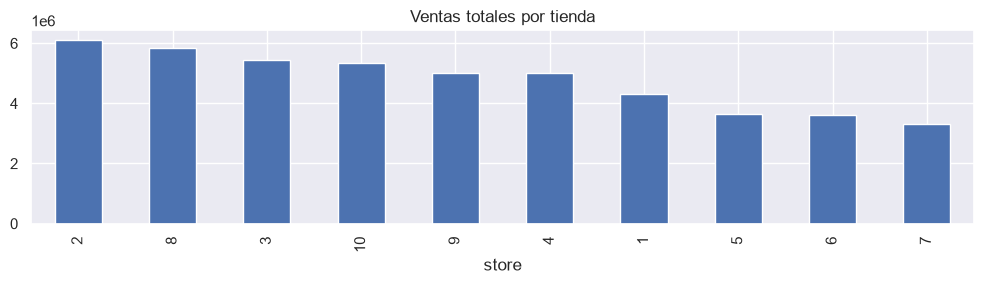

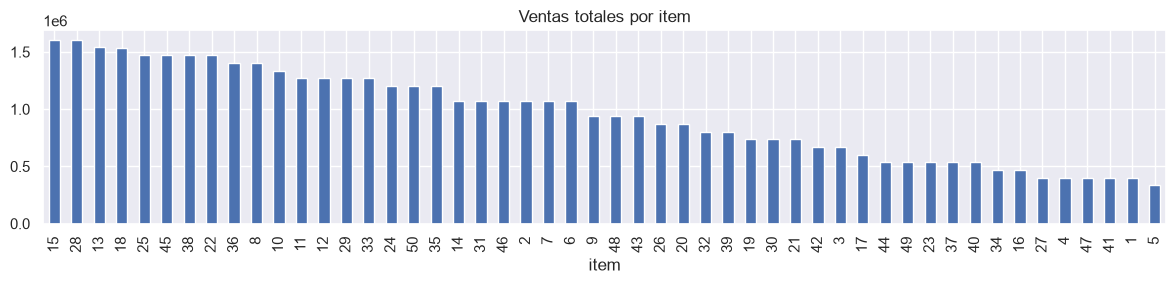

In [8]:
# Ventas totales por tienda
store_sales = df.groupby("store")["sales"].sum().sort_values(ascending=False)
ax = store_sales.plot.bar(figsize=(10, 3), title="Ventas totales por tienda")
plt.tight_layout(); plt.show()

# Ventas totales por item
item_sales = df.groupby("item")["sales"].sum().sort_values(ascending=False)
ax = item_sales.plot.bar(figsize=(12, 3), title="Ventas totales por item")
plt.tight_layout(); plt.show()

## 5. Exploración visual de la serie de tiempo

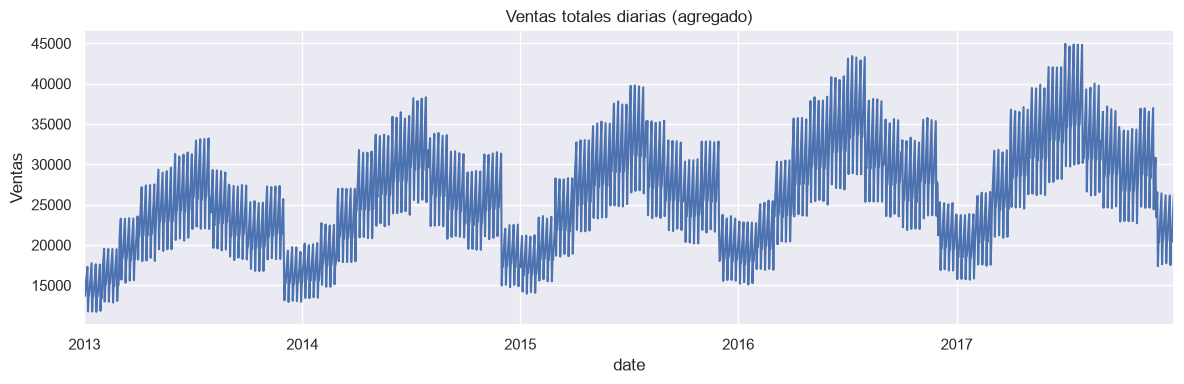

In [9]:
# Serie agregada (todas las tiendas/items): tendencia y estacionalidad
daily = df.groupby("date")["sales"].sum()
fig, ax = plt.subplots(figsize=(12, 4))
daily.plot(ax=ax, title="Ventas totales diarias (agregado)")
ax.set_ylabel("Ventas")
fig.tight_layout(); fig.savefig(FIGURES / "total_sales_daily.png", dpi=150); plt.show()

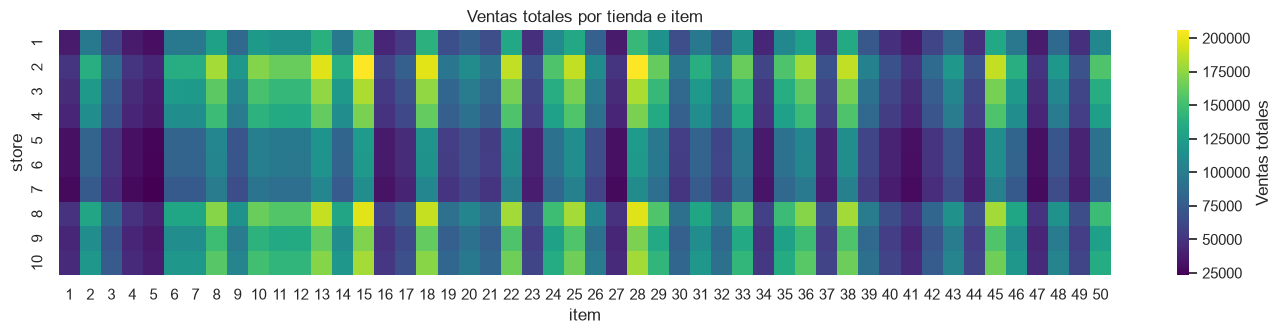

In [10]:
# Heatmap de ventas totales: tienda (filas) x item (columnas)
pivot = df.pivot_table(index="store", columns="item", values="sales", aggfunc="sum")
fig, ax = plt.subplots(figsize=(14, 3.5))
sns.heatmap(pivot, cmap="viridis", ax=ax, cbar_kws={"label": "Ventas totales"})
ax.set_title("Ventas totales por tienda e item")
fig.tight_layout(); fig.savefig(FIGURES / "heatmap_store_item.png", dpi=150); plt.show()

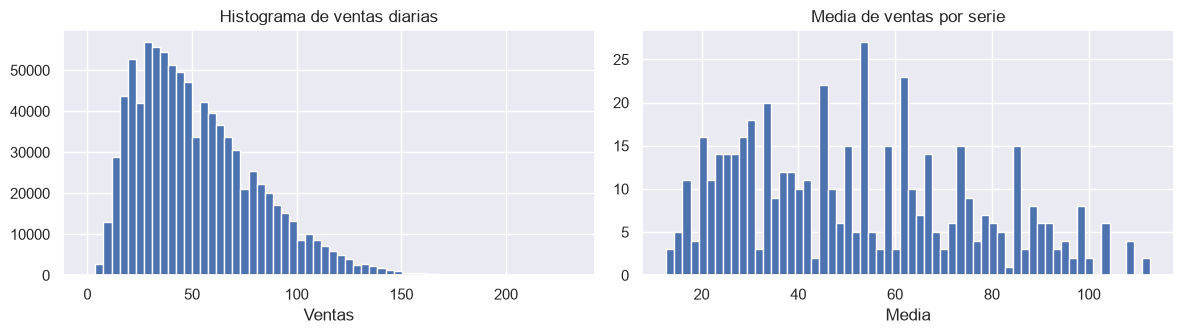

In [11]:
# Distribución de ventas
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
df["sales"].hist(bins=60, ax=axes[0])
axes[0].set_title("Histograma de ventas diarias")
axes[0].set_xlabel("Ventas")
# Ventas medias por serie (para ver la heterogeneidad entre las 500 series)
mean_by_series = df.groupby(["store", "item"])["sales"].mean()
mean_by_series.hist(bins=60, ax=axes[1])
axes[1].set_title("Media de ventas por serie")
axes[1].set_xlabel("Media")
fig.tight_layout(); fig.savefig(FIGURES / "distribucion_ventas.png", dpi=150); plt.show()

## 6. Descomposición de una serie representativa

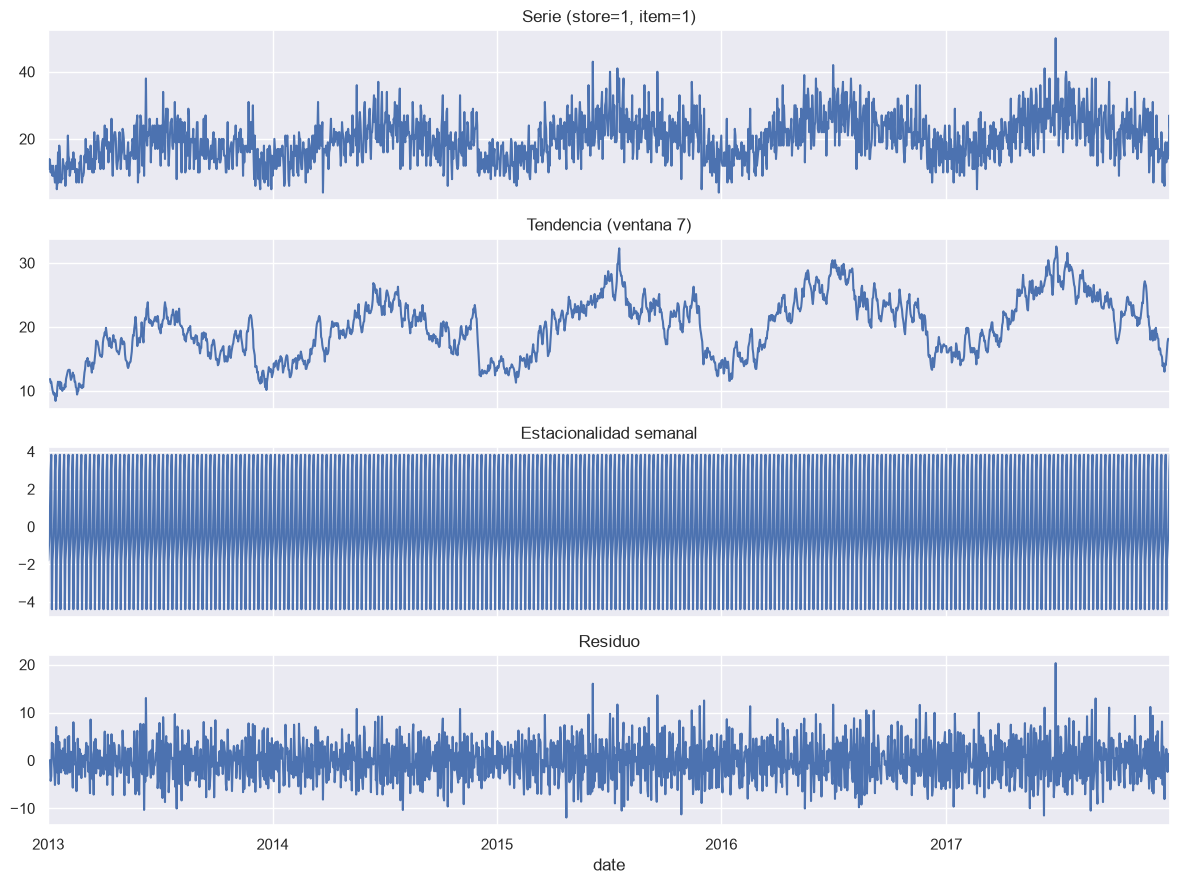

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

STORE, ITEM = 1, 1
s = df[(df["store"] == STORE) & (df["item"] == ITEM)].set_index("date")["sales"].sort_index()
res = seasonal_decompose(s, model="additive", period=7)

fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
s.plot(ax=axs[0]); axs[0].set_title(f"Serie (store={STORE}, item={ITEM})")
res.trend.plot(ax=axs[1]); axs[1].set_title("Tendencia (ventana 7)")
res.seasonal.plot(ax=axs[2]); axs[2].set_title("Estacionalidad semanal")
res.resid.plot(ax=axs[3]); axs[3].set_title("Residuo")
fig.tight_layout(); fig.savefig(FIGURES / "descomposicion_serie.png", dpi=150); plt.show()

## 7. Split temporal (sin fuga de datos)

In [13]:
# Entrenamos con todo excepto los últimos 3 meses, que serán el holdout (oct-dic 2017).
# OJO: el split es TEMPORAL (por fecha), nunca aleatorio, para respetar el orden de la serie.
SPLIT_DATE = "2017-10-01"

train = df[df["date"] < SPLIT_DATE].copy()
holdout = df[df["date"] >= SPLIT_DATE].copy()

print(f"Train  : {train['date'].min().date()} a {train['date'].max().date()} | {len(train):,} filas")
print(f"Holdout: {holdout['date'].min().date()} a {holdout['date'].max().date()} | {len(holdout):,} filas")
print(f"Proporción de datos en holdout: {len(holdout)/len(df)*100:.2f}%")

Train  : 2013-01-01 a 2017-09-30 | 867,000 filas
Holdout: 2017-10-01 a 2017-12-31 | 46,000 filas
Proporción de datos en holdout: 5.04%


## 8. Guardado de datos procesados

In [14]:
PROCESSED.mkdir(parents=True, exist_ok=True)
train.to_csv(PROCESSED / "train.csv", index=False)
holdout.to_csv(PROCESSED / "holdout.csv", index=False)
print("Guardado: data/processed/train.csv y data/processed/holdout.csv")

Guardado: data/processed/train.csv y data/processed/holdout.csv


In [15]:
# Nota: test.csv de la competición (ene-mar 2018, sin ventas) se usará en predict.py
# para el forecast "en producción" sobre el modelo registrado.
test_raw = pd.read_csv(RAW / "test.csv")
print(f"test.csv: {test_raw.shape[0]:,} filas | fechas {test_raw['date'].min()} a {test_raw['date'].max()}")
test_raw.head()

test.csv: 45,000 filas | fechas 2018-01-01 a 2018-03-31


,id,date,store,item
0,0,2018-01-01,1,1
1,1,2018-01-02,1,1
2,2,2018-01-03,1,1
3,3,2018-01-04,1,1
4,4,2018-01-05,1,1


## Conclusiones del EDA

- Dataset limpio: 913,000 filas, **0 nulos**, sin duplicados ni valores negativos, series diarias completas.
- **500 series** (10 tiendas × 50 items) de 2013 a 2017 → frecuencia diaria.
- Fuerte **estacionalidad semanal y anual** (visible en agregado y en descomposición).
- Gran **heterogeneidad** entre series (media de ventas muy variable) → usar **MASE** (escalado vs naive) para comparar entre series.
- Split temporal: train hasta 2017-09-30, holdout oct-dic 2017 (equivale a los 3 meses de pronóstico).